# Basics

In this example we explain the basic usage of the nest-soc package for modeling a solid oxide cell.

The package is currently divided into seven parts:
* **constants** : defines the main constants used in the package;
* **properties** : defines the gas species, mixtures, and their thermodynamic and mass transfer properties;
* **layers** : helps to define the solid oxide cell layers and their kinetic and transport properties;
* **cell** : helps to define a cell/single repeating unit from layers and contains solving routines for calculating operating variables (i.e., voltage, current, etc.);
* **boundary** : helps to define the inlet condition of the feedstock and air flow rates, as well as the fixed operating conditions;
* **degradation** : helps to define degradation mechanisms that affect kinetic and/or ohmic resistances during cell operation; 
* **eis** : helps to simulate electrochemical impedance spectroscopy;

After installing the package (see [0_installation.ipnynb](0_installation.ipynb)), we can import it to use in our code.

In this simple example, we will only require the packages properties, layers, cell, and boundary:

In [1]:
from nest import properties, layers, cell, boundary

## Species and Mixture

### Species

Let's start by defining the species involved in the simulation. 

The nest package provide some predefined species as part of an object called **BasicSpecies** defined in the subpackage properties.

The predefined species are:
* H2
* H2O
* O2
* N2
* CO
* CH4

So, for instance, the specie H2 can be accessed as:

        H2 = properties.BasicSpecies.H2

Let's include H2, H2O, and O2 species:

In [2]:
H2 = properties.BasicSpecies.H2
H2O = properties.BasicSpecies.H2O
O2 = properties.BasicSpecies.O2

### Mixture

Now, we should define fuel and air mixture for our solid oxide cell.

For this, we need to create a **Mixture** class that contains the **Species** classes representing our chemical species.

For example a mixture (fuel) containing H2 and H2O, would be defined as:

        fuel = properties.Mixture((H2, H2O))

**Note** : The mixture class accepts a **Tuple** and not directly the elements

Thus, let's define both the fuel (H2,H2O) as the air (O2) mixtures in our case:

In [3]:
fuel_mix = properties.Mixture((properties.BasicSpecies.H2, properties.BasicSpecies.H2O))
air_mix = properties.Mixture((properties.BasicSpecies.O2))

## Layers: kinetic, transport, and conductivity

Now that we have the species, we should define the solid oxide cell.

In order to make this procedure general and customizable, nest-soc uses **Layer** objects which represent each layer of the solid oxide cell.

The basic declaration of a **Layer** is to define a thickness. For instance, for an electrolyte YSZ of 10 micrometers:

        YSZ = layers.Layer(delta=10e-6)

This creates a simple 10 micrometer layer without any property.

In [4]:
YSZ = layers.Layer(delta=10e-6)

There are four types of properties that a **Layer** can hold:
* **kinetic**: related to the rate of electrochemical reactions;
* **transport** : related to diffusion properties of gases in a porous media;
* **conductivity** : related to the conductivity of electrons/ions across the layer;
* **degradation** : related to how kinetic and conductivity properties change over time;

For the case of an electrolyte, we need to define only its conductivity properties.

### Conductivity
The conductivity is calculated from a general expressions:

$$ \sigma = \sigma_0 T^{\theta} \exp{\left ( \frac{E_{act}}{RT} \right )} $$

In which:
* $\sigma$ : conductivity at specific temperature T [S/m];
* $ T $ : temperature [K]
* $R$ : gas constant [J/mol.K]
* **$\sigma_0$ : reference conductivity [S/m]**;
* **$E_{act}$ : activation energy [J/mol]**;
* **$\theta$ : temperature exponential factor [-]**;

**Note**: Bold variables are fitted parameters that should be given to the model.

Thus, we can complete the definition of the YSZ layer, by overwriting its conductivity to the values reported on from literature.

For example:

$$ \sigma = 3.6 \cdot 10^6 \cdot  T  \exp{\left ( \frac{8 \cdot 10^4}{RT} \right )} $$

In the code:


In [5]:
YSZ.conductivity = layers.Conductivity(
    sigma0=3.6e7,
    E_act=8e4,
    theta=1,
)

Likewise, we can define the remaining electrolyte layers, which in this case are CGO and an inter-diffusion layer between YSZ and CGO:

In [6]:
CGO = layers.Layer(
    delta=10e-6 - 2e-6,
    conductivity=layers.Conductivity(
        sigma0=1.09e7,
        E_act=0.64 / 8.617333262e-5 * 8.314510,
    ),
)

# Inter-diffusion layer between YSZ and CGO, properties were fitted with experimental data
YSZ_CGO = layers.Layer(
    delta=4e-6,
    conductivity=layers.Conductivity(sigma0=1715, E_act=8785 * 8.314510, theta=0),
)

### Kinetic
To complete the cell, we should define the fuel and air electrodes layers.

In these layers, we need to define a kinetic attribute which will be used to calculate the reaction rates for consuming/producing species.

From the Faraday law, we know that:

$ r_i = \nu_i \frac{j}{n_e*F} $

In which,
* $r_i$ : reaction rate of specie i per area [mol/m^2.s]
* **$\nu_i$ : stoichiometric factor of specie i in the reaction [-]**
* $j$ : current density [A/m^2]
* **$n_e$ : number of electrons exchanged per mole of main reactant [-]**
* $F$ : Faraday constant [A.s/mol]

Here, we are going to assume kinetics can be represented by a Butler-Volmer equation:

$$j = j_0 \left [ \exp \left( \alpha \frac{n_e F}{RT}\eta_{act} \right) - \exp \left( -\beta \frac{n_e F}{RT} \eta_{act} \right) \right] $$

In which,

$$ j_0 = \gamma T^\theta  \exp \left ( \frac{E_{act}}{RT} \right) \prod_i \left( \frac{P_i}{P_0} \right)^{p_i} $$

* $j_0$ : exchange current density [A/m^2]
* **$\gamma$ : pre-exponential factor for exchange current density [A/m^2]**
* **$\theta$ : exponential factor for temperature dependency [-]**
* **$E_{act}$ : activation energy for exchange current density [J/mol]**
* $P_i$ : partial pressure of specie i [Pa]
* $P_0$ : reference pressure [Pa]
* **$p_i$ : partial pressure exponential factor [-]**
* **$\alpha$ : charge transfer coefficient - forward reaction [-]**
* **$\beta$ : charge transfer coefficient - backward reaction [-]**

There are many parameters which should be given to complete a kinetic of a Butler-Volmer reaction (i.e., bold variables).

These parameters can be found on literature and/or calibrated based on experiments.

For the sake of simplicity, here we are going to take for granted some pre-fitted parameters to describe the fuel and air electrode (i.e., Ni-YSZ and LSCF-CGO):


In [7]:
# Fuel electrode
Ni_YSZ = layers.Layer(
    delta=3e-4 + 10e-6,
    kinetic=layers.ButlerVolmer(
        gas=fuel_mix,
        alpha=0.59,
        beta=1 - 0.59,
        gamma=0.56 * 1.82527e6,
        theta=1,
        nu=[-1, 1],
        E_act=1.09 / 8.617333262e-5 * 8.314510,
        p=[-0.1, 0.33],
        n_e=2,
    ),
)

# Air electrode
LSCF_CGO = layers.Layer(
    delta=3e-5,
    kinetic=layers.ButlerVolmer(
        gas=air_mix,
        alpha=0.65,
        beta=1 - 0.65,
        gamma=1.51556e8,
        nu=[-0.5],
        E_act=1.45 / 8.617333262e-5 * 8.314510,
        p=[0.22],
    ),
)

Note:
1. The gas mixture is also included in the kinetic object as the **gas** attribute;
2. **nu** and **p** need to be given as arrays, in which the elements follow the same order as the gas mixture;

So, for instance, in our example:
* $\nu_{H2}$ = -1 (Hydrogen is consumed in the reaction)
* $\nu_{H2O}$ = 1 (Water is produced in the reaction)

And in the code appears as:

        nu = [-1, 1]

Because our reference reaction is:

$$ H_2 + \frac{1}{2} O_2 \rightarrow H_2O $$

and the *fuel_mix* was declared as (i.e., first H2, secondly H2O):

        fuel_mix = properties.Mixture((properties.BasicSpecies.H2, properties.BasicSpecies.H2O))


### Transport

Since the electrodes are porous layers, gases can diffuse from the channels to the reaction zones.

In nest-soc, we can model this by overwriting the **transport** attribute of a **Layer**.

In the simplest case, we can add a Binary Fick diffusion model (i.e., **BinaryFick**) which only requires three material properties:

* **$d_p$ : diameter of the porous [m]**;
* **$\epsilon$ : porosity of the layer [-]**;
* **$\tau$ : tortuosity of the layer [-]**;

In our case, this translates to the following lines of code:

In [8]:
Ni_YSZ.transport = layers.BinaryFick(dp=6e-7, epsilon=0.3, tau=3)
LSCF_CGO.transport = layers.BinaryFick(dp=6e-7, epsilon=0.3, tau=2.8)

## Cell and Boundary

### Cell

Now that we have completed the definition of all **Layer**, we can bundle them together as a cell using the class **Cell**.

For this we need to define the cell area and specify the layers function (i.e., fuel electrode, air electrode and electrolyte).

For instance, in our case, for a 16 $cm^2$ cell we can use the following declaration:

In [9]:
DTU_cell = cell.Cell(
    area=16e-4,
    electrode_fuel=Ni_YSZ,
    electrolyte=(YSZ, YSZ_CGO, CGO),
    electrode_air=LSCF_CGO,
)

**Note** : the area should be given in $m^2$ following the SI convention.

### Boundary

Finally, we need to provide the basic information on the surrounding boundary conditions to complete a simulation.

This is analogous to the experimental conditions in which a test is performed. 

Here, the boundary conditions refer to the inlet conditions of flows and the voltage and/or current applied to the cell:

* n_fuel : molar flow rate of the fuel side [mol/s]
* n_air : molar flow rate of the air side [mol/s]
* T : inlet temperature [K]
* P : inlet pressure [Pa]
* V : cell voltage [V]
* j : cell current density [A/cm^2]

Thus, an experimental setup consisting of:
* 24 L/min fuel flow, 50 % H2 and 50% H2O
* 50 L/min air flow, 100 % O2
* 858 degree Celsius
* 1 bar pressure
* 1.25 V of cell voltage

can be defined as:

In [10]:
n_fuel = 24 / 1e3 / 3600 * (1e5 / 8.314510 / 273.15)  # mol/s
n_air = 50 / 1e3 / 3600 * (1e5 / 8.314510 / 273.15)  # mol/s
x_H2 = 0.5
x_O2 = 1

conditions = boundary.BoundaryData(
    V=1.25,
    j=-0.5e4,  # guess for root-finding algorithm
    n_fuel=[n_fuel * x_H2, n_fuel * (1 - x_H2)],
    n_air=[n_air * x_O2],
    T=858 + 273.15,
    P=1e5,
)

As you can notice, we also included a current density into the conditions although this is our simulation goal.

This current density value will serve as a guess to the root-finding algorithm, improving the stability of the simulation.

**Note:**
1. The variables need to be converted to SI units
2. The molar flow rates are included as arrays, following the order specified in the mixture included in the kinetic model
3. Current density (or voltage) can be supplied as an initial guess for root-finding algorithms.

## Solving problem and checking results

Now, we can simply solve the problem for the boundary conditions given.

In this case, as we specified the voltage, we should solve for voltage using the internal method **solve_for_voltage** giving the test conditions:

In [11]:
solution = DTU_cell.solve_for_voltage(conditions)

The solutions are provided as a double index array, in which:
* the first index refers to a specific variable
* the second index refers to the segment number in the conversion axis

The nest-soc solves the electrochemical problem by using a finite element method, meaning that the whole cell is dived into a specific number of segments.

This allows an ordinary differential equation system to be solved as an algebraic system of equations.

For instance, the index number **zero** (solution[0]) holds the **voltage** values for each segment:

In [12]:
solution[0]

array([1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25])

while the index number one (solution[1]) holds the current density values for each segment: 

In [13]:
solution[1]

array([-22163.37547008, -20493.9463812 , -18838.27959669, -17183.38213244,
       -15523.81537708, -13862.25982854, -12210.465533  , -10589.60612625,
        -9029.15068838,  -7562.99978204])

As it can be observed, the current density is higher at the inlet (in absolute terms).

This happens because steam is converted into hydrogen along the cell, increasing the thermodynamic voltage and activation overpotential (i.e., losses) along of the later segments.

We can plot the results to better visualize it:

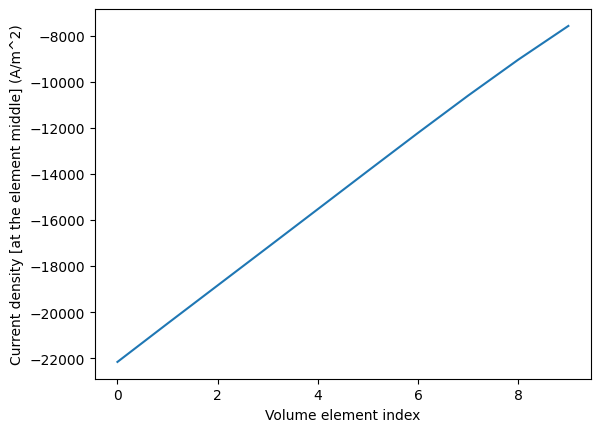

In [14]:
from matplotlib import pyplot as plt

plt.plot(solution[1])  # Assuming the cell is a square with 4 cm length on each side
plt.xlabel("Volume element index")
plt.ylabel("Current density [at the element middle] (A/m^2)")
plt.show()

The current density reported in experiments is the weighted average between all segments.

Since the segments are all equal in size, the average current density is the average current density of all segements.


In [15]:
import numpy as np

print(f"The average current density is {np.average(solution[1])} A/cm2")

The average current density is -14745.728091568953 A/cm2


In most cases, one would only like to know the average current or the voltage applied into a cell, meaning that mainly indexes 0 and 1 are interesting.

The other indexes hold some important information for degradation modeling or in-depth analysis. They are:

* [0] = Voltage
* [1] = Current density (at the **middle** of each segment)
* [2] = Temperature
* [3] = Pressure
* [4-3+len(n_fuel)] = Molar flow rate of fuel flow (at the **end** of each segment)
* [4+len(n_fuel):4+len(n_fuel)+len(n_air)] = Molar flow rate of air flow (at the **end** of each segment)
* [4+len(n_fuel)+len(n_air)+1] = Activation overpotential of fuel electrode (at the **middle** of each segment)
* [4+len(n_fuel)+len(n_air)+2] = Activation overpotential of air electrode (at the **middle** of each segment)
* [4+len(n_fuel)+len(n_air)+3:] = Ohmic overpotential of electrolyte layers (at the **middle** of each segment)

For instance, plotting the molar flow rate of the fuel flows can be achieved by:


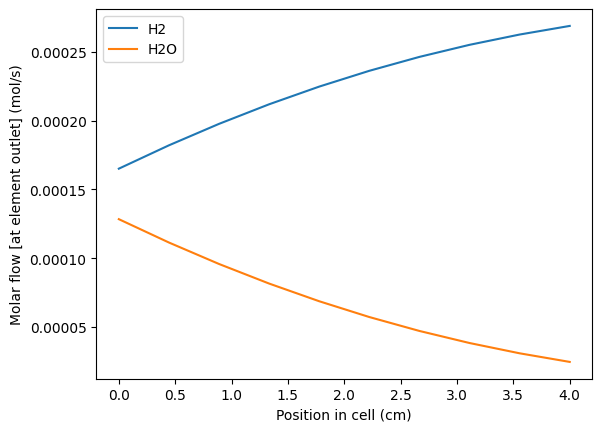

In [16]:
plt.plot(
    np.linspace(0, 4, num=10), np.transpose(solution[4:6]), label=["H2", "H2O"]
)  # Assuming the cell is a square with 4 cm length on each side
plt.xlabel("Position in cell (cm)")
plt.ylabel("Molar flow [at element outlet] (mol/s)")
plt.legend()
plt.show()

**Note**: the molar flow rates are given for the **end of a segment** while the current densities are given for the **middle of a segment**

## Activity 1: plotting a polarization curve

**Problem** : Using the cell defined in this example, plot the polarization curve of the cell test varying the voltage from 1.25 V to 0.7 V and compare with [experimental data](../data/858C_50H2_100O2.csv).

**Answer**: Here is a code example that accomplishes this task

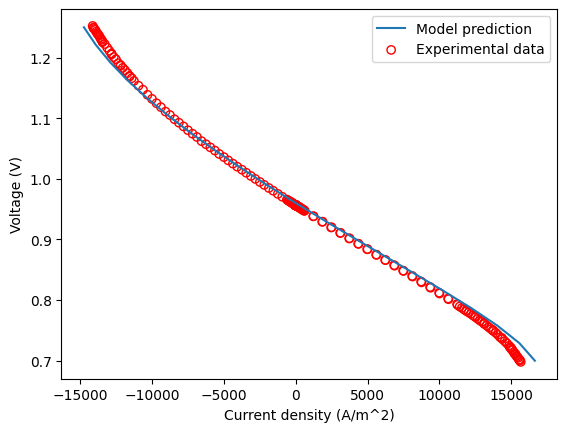

In [17]:
# 1. Import pandas to handle the csv experimental data
import pandas as pd

# 2. Create the array to hold current densities and spams across the voltage range
current_densities = np.zeros(20)
voltages = np.linspace(0.7, 1.25, num=20)

# 3. Loop the simulation for the voltage values updating the boundary conditions
for i, V in enumerate(voltages):
    conditions.V = V
    solution = DTU_cell.solve_for_voltage(conditions)
    current_densities[i] = np.average(solution[1])

# 4.  Import the experimental data set
dataset = pd.read_csv("../data/858C_50H2_100O2.csv")

# 5. Plot the model prediction and the experimental data
plt.plot(current_densities, voltages, label="Model prediction")
plt.scatter(
    dataset["j"] * 1e4,
    dataset["V"],
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
plt.xlabel("Current density (A/m^2)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

## Activity 2: making a "lazy" cell model

**Problem**: Using the [experimental data](../data/858C_50H2_100O2.csv), fit an average area specific resistance and build a "lazy" model with just one layer that represents the solid oxide cell.

**Answer**: Here is a code example that accomplishes this task

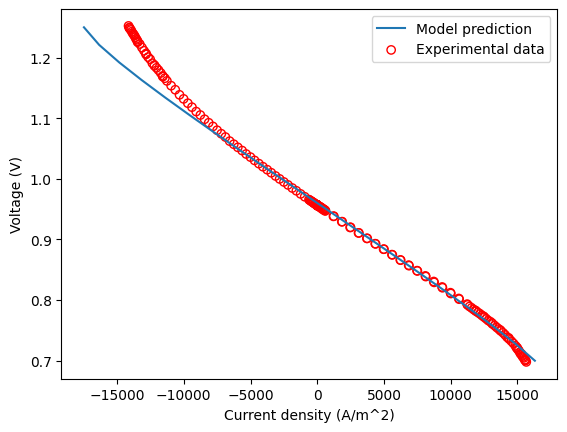

In [18]:
# 1. Create an equivalent layer to represent the cell resistance
ASR = 0.12  # Ohm*cm2, estimated from the experimental data near the OCV
equivalent_layer = layers.Layer(
    delta=1,
    conductivity=layers.Conductivity(
        sigma0=1e4 / ASR,  # converted into S/m
        theta=0,  # Important to set theta as zero, because the default is 1
    ),
)

# 2. Create dummy layers for the electrodes with the minimal data required for the molar balances and thermodynamic voltage calculation
dummy_fuel = layers.Layer(
    delta=1,
    kinetic=layers.Kinetic(gas=fuel_mix, nu=[-1, 1]),
)
dummy_air = layers.Layer(
    delta=1,
    kinetic=layers.Kinetic(gas=air_mix, nu=[-0.5]),
)

# 3. Create the cell with the equivalent layer and dummy electrodes
lazy_cell = cell.Cell(
    area=16e-4,
    electrode_fuel=dummy_fuel,
    electrolyte=(equivalent_layer,),
    electrode_air=dummy_air,
)

# 4. Copying the last activity code to generate a polarization curve
current_densities = np.zeros(20)
voltages = np.linspace(0.7, 1.25, num=20)
for i, V in enumerate(voltages):
    conditions.V = V
    solution = lazy_cell.solve_for_voltage(conditions)
    current_densities[i] = np.average(solution[1])
plt.plot(current_densities, voltages, label="Model prediction")
plt.scatter(
    dataset["j"] * 1e4,
    dataset["V"],
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
plt.xlabel("Current density (A/m^2)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()